# Robustness Analysis: Adjoint and Toggle-Frame Objectives Subject to Either Multiplicative or Additive Errors

This notebook compares the performance of the adjoint and toggling-frame robustness objectives for multiplicative and additive error terms in the system's Hamiltonian. 

## Imports

In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using Plots
using SparseArrays
using Statistics
using CairoMakie
using Random
⊗ = kron;

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `QuantumCollocation

ArgumentError: ArgumentError: Package Plots not found in current path.
- Run `import Pkg; Pkg.add("Plots")` to install the Plots package.

In [2]:
# Problem parameters
F = 0.999 # target fidelity
Random.seed!(5)
T = 40
Δt = 0.2
num_iter = 2000
iSWAP = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
SWAP = ComplexF64[1 0 0 0;
                    0 0 1 0;
                    0 1 0 0;
                    0 0 0 1]
U_goal = iSWAP

X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z
XX = GATES.X ⊗ GATES.X # transversal coupling
YY = GATES.Y ⊗ GATES.Y # transversal coupling
ZZ = GATES.Z ⊗ GATES.Z # transverse coupling, for error comparison
XY = GATES.X ⊗ GATES.Y
YX = GATES.Y ⊗ GATES.X
XZ = GATES.X ⊗ GATES.Z
ZX = GATES.Z ⊗ GATES.X
YZ = GATES.Y ⊗ GATES.Z
ZY = GATES.Z ⊗ GATES.Y

H_drive = [X1, Y1, Z1, X2, Y2, Z2, XX] # single qubit controls + tunable coupling
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)

UndefVarError: UndefVarError: `Random` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: Random is loaded but not imported in the active module Main.

In [17]:
# Universal 
f_uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt, a_bound = 2.0, dda_bound=10.0;
    activate_hyperspeed=true,
    piccolo_options=piccolo_opts
    )
push!(f_uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, f_uni_prob.trajectory))
solve!(f_uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(f_uni_prob, max_iter=50, print_level=5)

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    24768
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1034
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      286
                     variables with only upper bounds:        0
Total number of equality constraints.................:      893
Total number o

In [18]:
# Default
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; a_bound = 2.0, dda_bound=10.0, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)

    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    24768
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1034
                     variables with only lower bounds:        0
                variables with lower and upper b

In [19]:
∂ₑHₐ = [ZZ] ;

In [20]:
# Toggling
Hₑ_add = a -> ∂ₑHₐ
add_prob = UnitarySmoothPulseProblem(
            sys, U_goal, T, Δt;
            a_bound = 2.0,
            dda_bound=10.0,
            piccolo_options=piccolo_opts,
            activate_rob_loss=true,
            H_err=Hₑ_add,
            Q_t=1.0
        )
push!(add_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, add_prob.trajectory))
solve!(add_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(add_prob, max_iter=50, print_level=5)

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    24768
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1034
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      286
                     variables with only upper bounds:        0
Total number of equality constraints.................:      893
Total number o

In [21]:
# Adjoint 

varsys_add = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)

var_count = length(∂ₑHₐ)

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for i in 1:var_count],
    a_bound = 2.0,
    dda_bound = 10.0,
    Q_r = 1.0,
    Q_s = 0.0,
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(varadd_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, varadd_prob.trajectory))
solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(varadd_prob, max_iter=50, print_level=5)

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    85312
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1642
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      286
                     variables with only upper bounds:        0
Total number of equality co

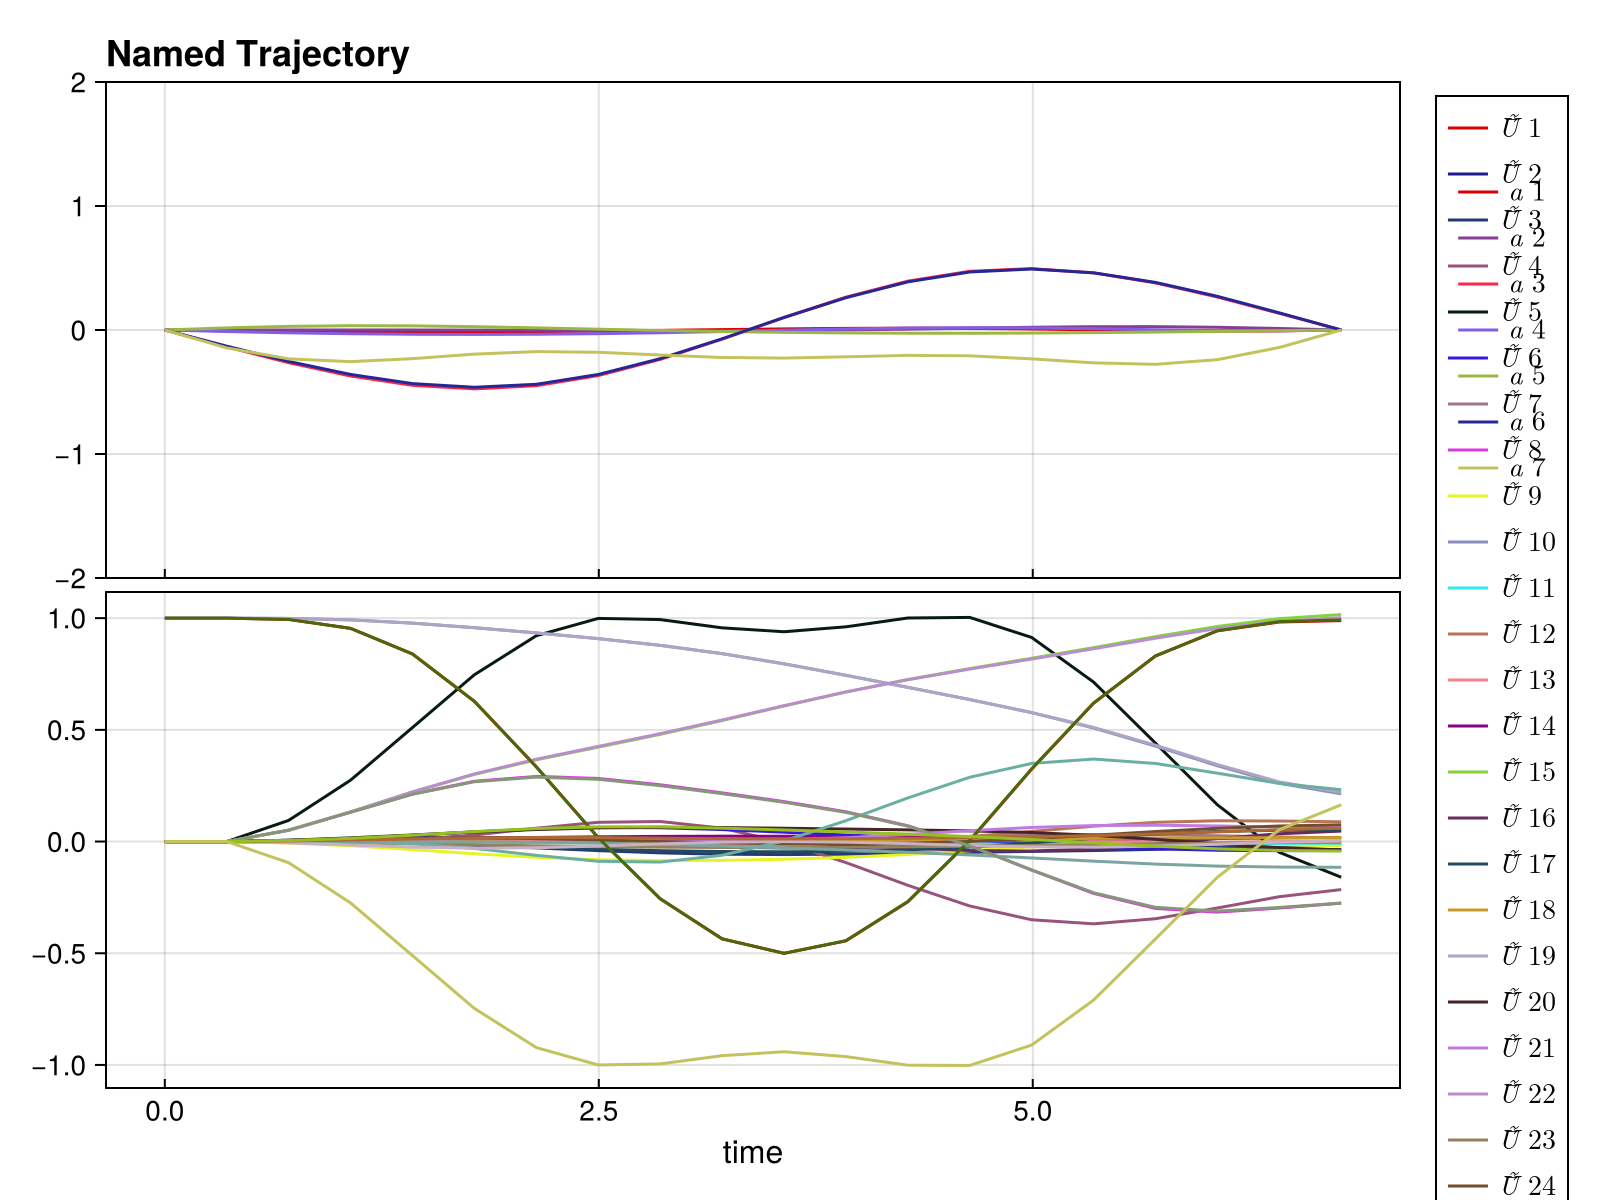

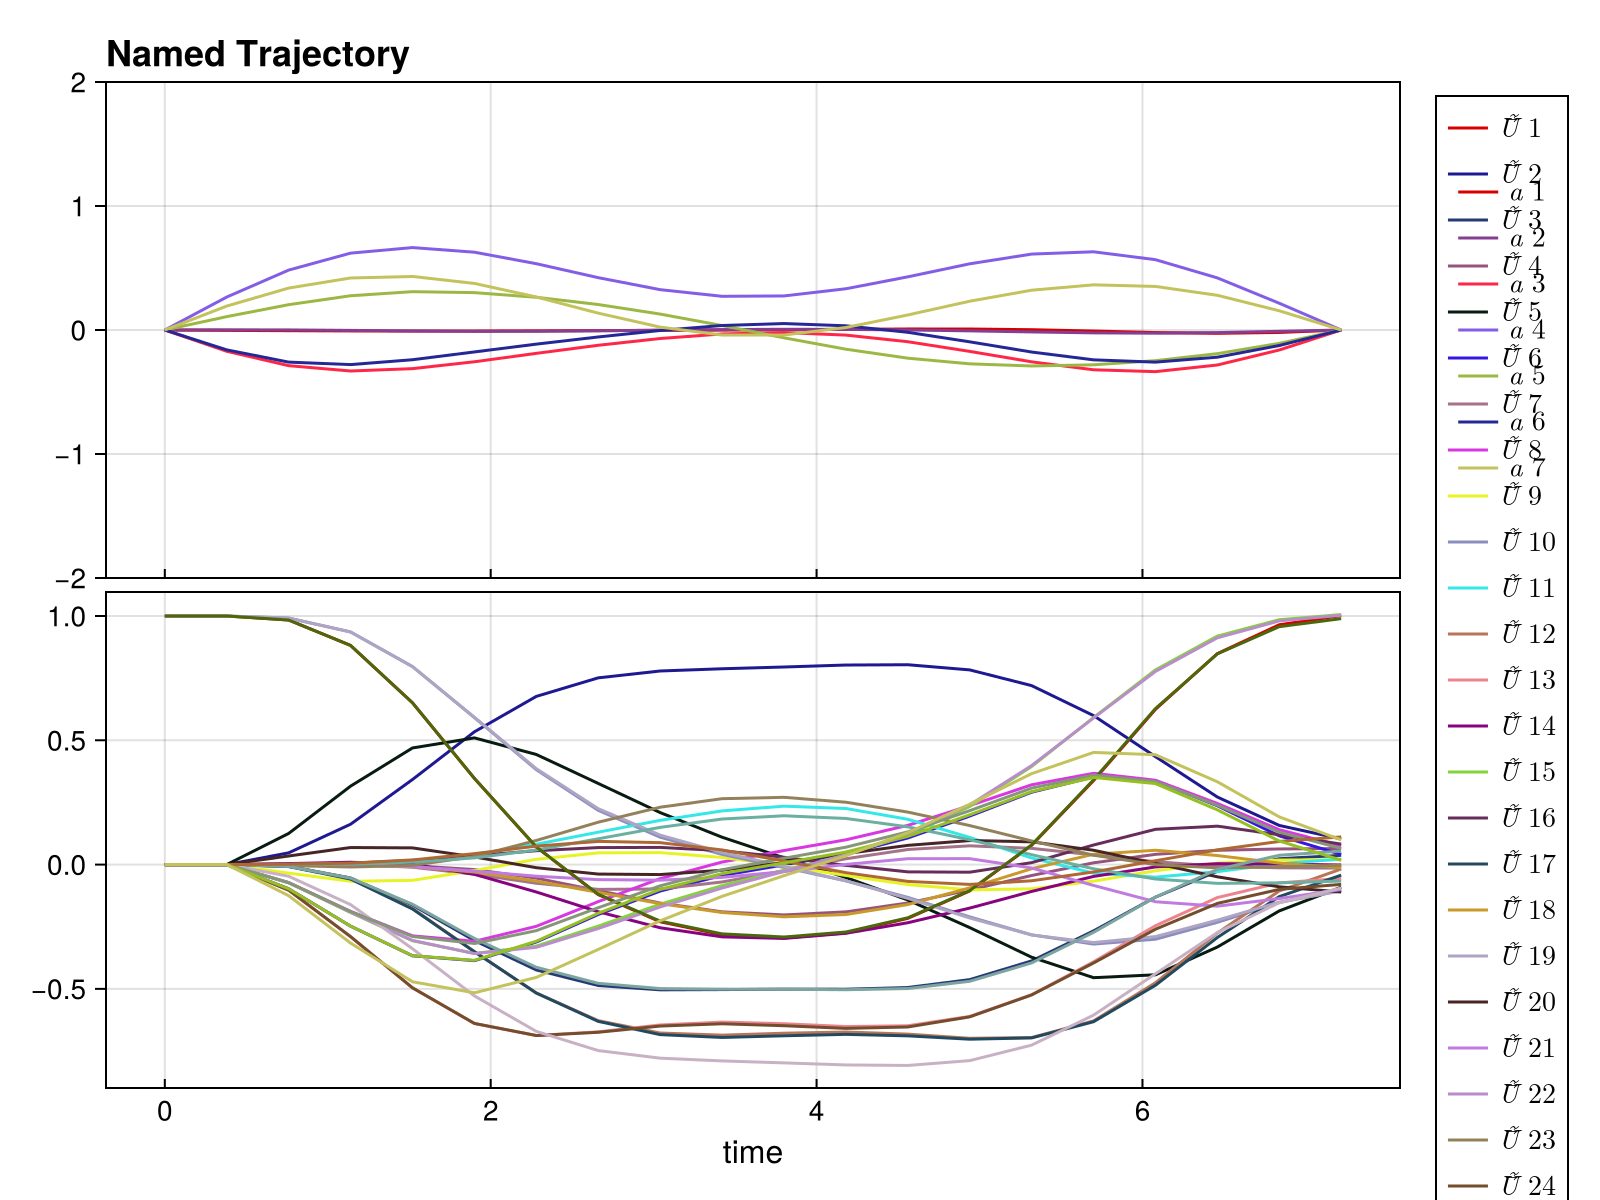

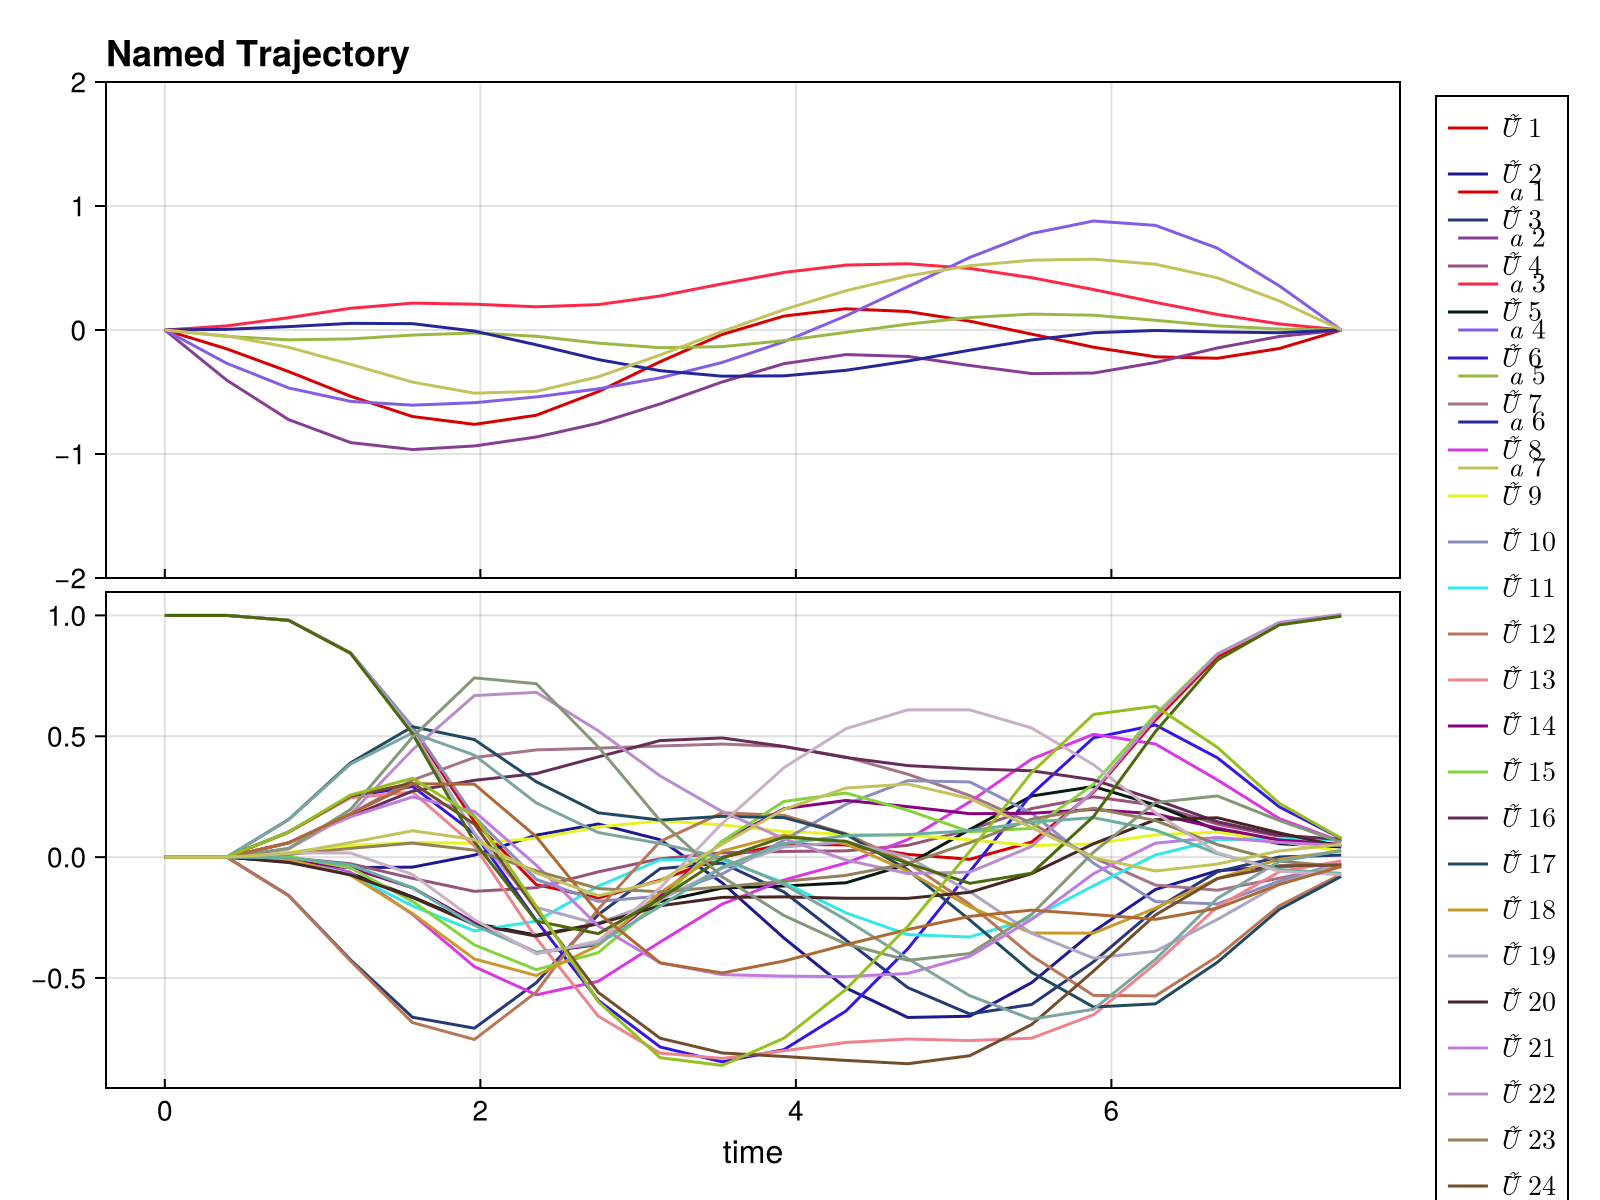

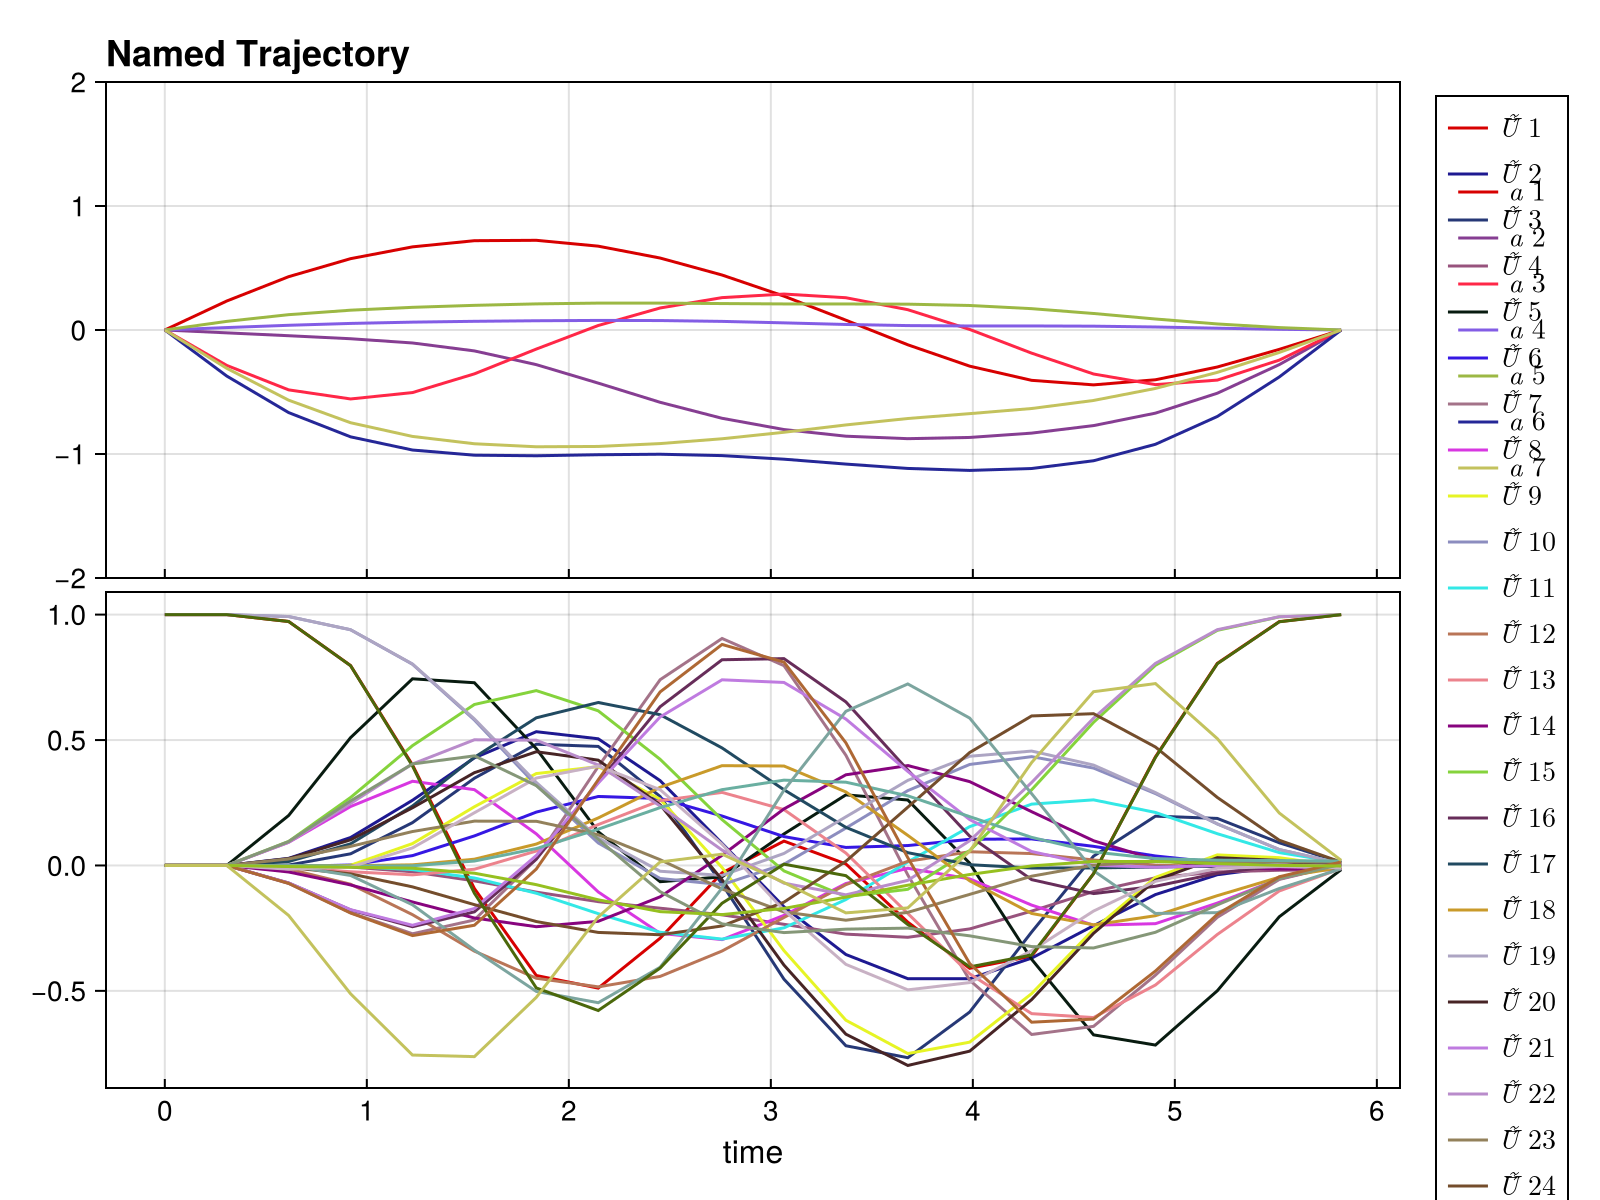

CairoMakie.Screen{IMAGE}


In [22]:
p1 = CairoMakie.plot(def.trajectory, [:a, :Ũ⃗])
p2 = CairoMakie.plot(varadd_prob.trajectory, [:a, :Ũ⃗])
p3 = CairoMakie.plot(add_prob.trajectory, [:a, :Ũ⃗])
p4 = CairoMakie.plot(f_uni_prob.trajectory, [:a, :Ũ⃗])

display(p1)
display(p2)
display(p3)
display(p4)

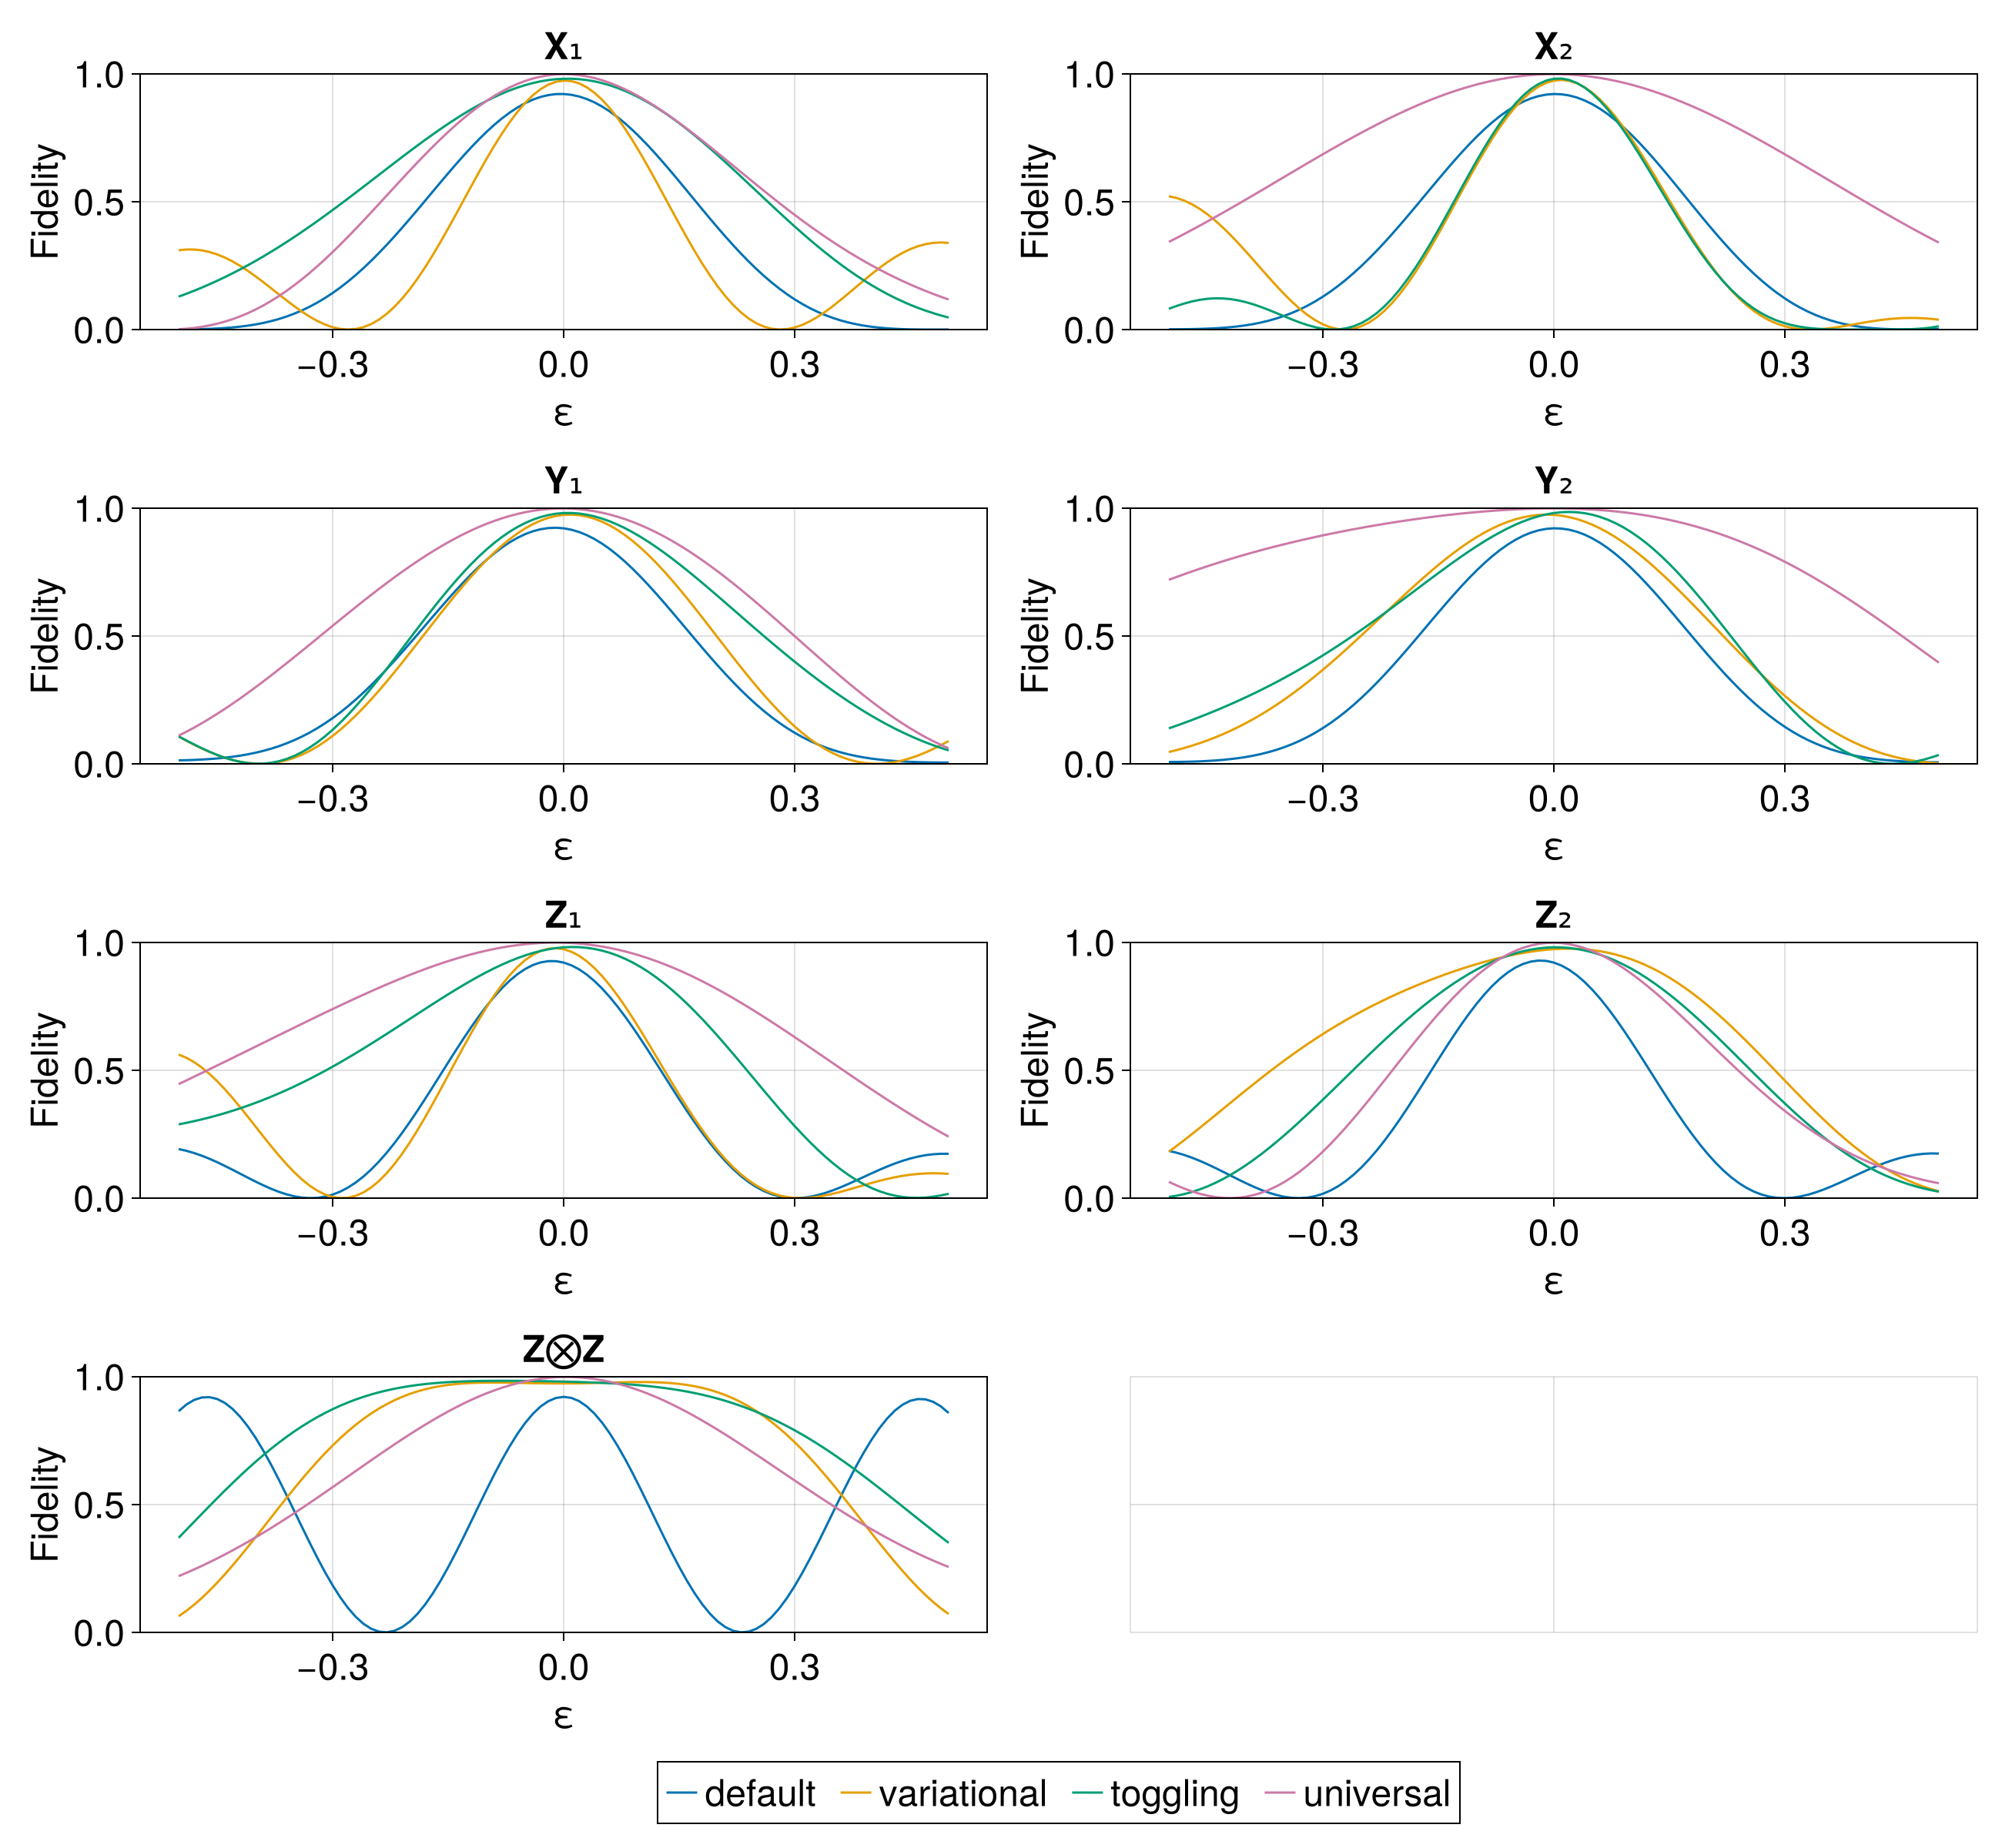

CairoMakie.Screen{IMAGE}


In [23]:
using CairoMakie

# --- Error ops & names (assumes X1,Y1,Z1,X2,Y2,Z2,ZZ already defined) ---
err_ops   = [X1, Y1, Z1, X2, Y2, Z2, ZZ]
err_names = ["X₁","Y₁","Z₁","X₂","Y₂","Z₂","Z⨂Z"]
colors = 

# --- Problems to compare (assumes `def`, `f_uni_prob`, and H_drive exist) ---
problems = [
    (def,        "default"),
    (varadd_prob,"variational"),
    (add_prob,   "toggling"),
    (f_uni_prob, "universal")
]

# Sweep & style
εs     = -0.5:0.01:0.5
colors = Makie.wong_colors()

# Helper: extract drive set to avoid DimensionMismatch
get_drives(prob) = hasproperty(prob, :system) && hasproperty(prob.system, :G) ? prob.system.G : H_drive

# Fidelity curve
fidelity_curve(prob, err_op) = [
    unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * err_op, get_drives(prob)))
    for ε in εs
]

# --- Figure & layout (2 columns for plots; bottom row legend) ---
f = Figure(fontsize = 24, size = (1300, 1200), padding = 16)
rowgap!(f.layout, 18)
colgap!(f.layout, 22)

# Left column -> X1,Y1,Z1,ZZ ; Right column -> X2,Y2,Z2 ; keep (4,2) blank
left_indices  = [1, 2, 3, 7]  # X1,Y1,Z1,ZZ
right_indices = [4, 5, 6]     # X2,Y2,Z2

for (r, idx) in enumerate(left_indices)
    name, op = err_names[idx], err_ops[idx]
    ax = Axis(f[r, 1], title = name, xlabel = "ε", ylabel = "Fidelity")
    Makie.ylims!(ax, 0, 1)
    for (i, (prob, _)) in enumerate(problems)
        lines!(ax, εs, fidelity_curve(prob, op); color = colors[i], linestyle = :solid)
    end
end

for (r, idx) in enumerate(right_indices)
    name, op = err_names[idx], err_ops[idx]
    ax = Axis(f[r, 2], title = name, xlabel = "ε", ylabel = "Fidelity")
    Makie.ylims!(ax, 0, 1)
    for (i, (prob, _)) in enumerate(problems)
        lines!(ax, εs, fidelity_curve(prob, op); color = colors[i], linestyle = :solid)
    end
end

# Bottom-right placeholder to keep panel sizes matched
ax_blank = Axis(f[4, 2]); hidespines!(ax_blank); hidedecorations!(ax_blank, grid = false)

# Shared legend on a new bottom row spanning both columns
labels  = [label for (_, label) in problems]
handles = [Makie.LineElement(color = colors[i], linestyle = :solid) for (i, _) in enumerate(problems)]
Legend(f[5, 1:2], handles, labels; title = "Legend", orientation = :horizontal)

display(f)

In [24]:
using NamedTrajectories

pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, YY, ZZ] 
uni_traj = f_uni_prob.trajectory
default_traj = def.trajectory

function SpaceCurve(traj::NamedTrajectory, U_goal::AbstractMatrix{<:Number}, H_err::AbstractMatrix{<:Number})
    T = traj.T
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))

    for i in 1:T
        U = iso_vec_to_operator(traj.Ũ⃗[:, i])
        first_order_integral += U' * H_err * U
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    space_curve = [[real(tr(op * first_order_terms[t] / (d * T))) for op in pauli_strings] for t in 1:T] 
    return space_curve
end

SpaceCurve (generic function with 1 method)

In [25]:
# Hₑ = Z2
# uni_curve = SpaceCurve(uni_traj, U_goal, Hₑ)
# default_curve = SpaceCurve(default_traj, U_goal, Hₑ)
# uni_G = [norm(v) for v in uni_curve]
# default_G = [norm(v) for v in default_curve]
# f = Figure(resolution = (800, 600))
# ax = Axis(f[1, 1], xlabel = "Index", ylabel = "‖G⃗(ZZ)‖", title = "Comparison of norms")

# lines!(ax, xs, uni_G;     color = :blue, label = "uni_G")
# lines!(ax, xs, default_G; color = :red,  label = "default_G")

# axislegend(ax; position = :rt)

# f


In [26]:
pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

last_uni = []
last_def = []
last_add = []
last_varadd = []

uni_traj = f_uni_prob.trajectory
default_traj = def.trajectory
add_traj = add_prob.trajectory
varadd_traj = varadd_prob.trajectory

for pauli in pauli_strings
    #print(Hₑ)
    uni_curve = SpaceCurve(uni_traj, U_goal, pauli)
    default_curve = SpaceCurve(default_traj, U_goal, pauli)
    add_curve = SpaceCurve(add_traj, U_goal, pauli)
    varadd_curve = SpaceCurve(varadd_traj, U_goal, pauli)
    uni_G = [norm(v) for v in uni_curve]
    add_G = [norm(v) for v in add_curve]
    varadd_G = [norm(v) for v in varadd_curve]
    default_G = [norm(v) for v in default_curve]
    a = copy(uni_G[end])
    b = copy(default_G[end])
    c = copy(add_G[end])
    d = copy(varadd_G[end])
    push!(last_uni, a)
    push!(last_def, b)
    push!(last_add, c)
    push!(last_varadd, d)
end

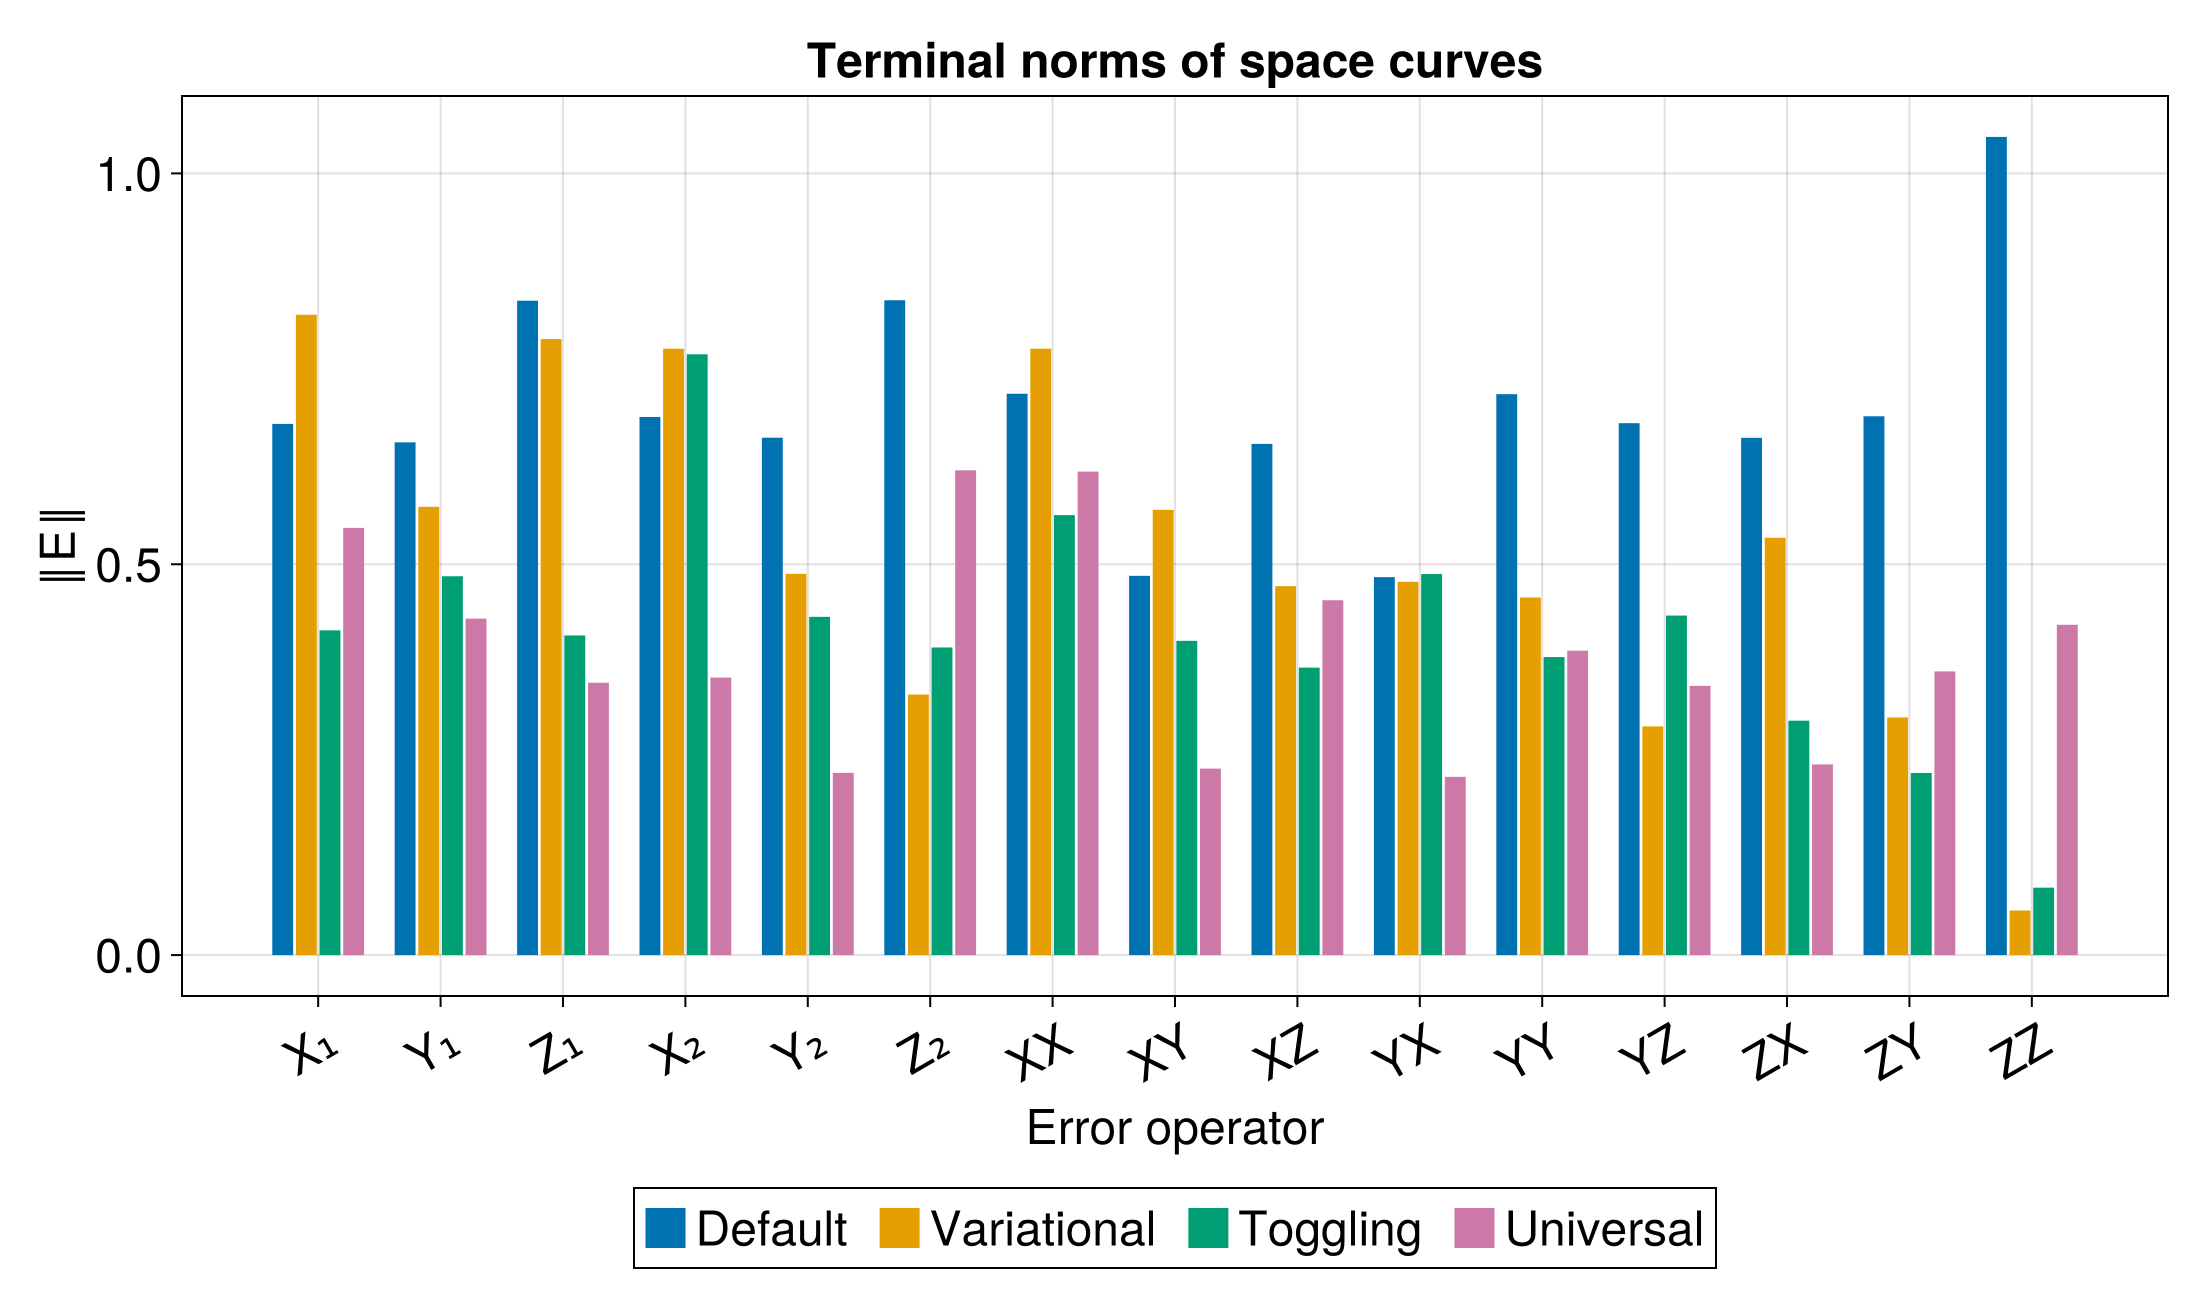

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/andrewkamen/.julia/packages/Makie/FUAHr/src/scenes.jl:238


CairoMakie.Screen{IMAGE}


In [27]:
using CairoMakie
const CM = CairoMakie

err_labels = ["X₁","Y₁","Z₁","X₂","Y₂","Z₂", "XX","XY","XZ","YX","YY","YZ","ZX","ZY","ZZ"]
n = length(err_labels)

# Interleave values per error label in the order: Default, Variational, Toggling, Universal
y = collect(Iterators.flatten(
        (last_def[i], last_varadd[i], last_add[i], last_uni[i]) for i in 1:n
))

# x index repeated 4 times (one per series) for each error label
x = repeat(1:n, inner = 4)              # 1,1,1,1, 2,2,2,2, ...
# group id per bar (1:Default, 2:Variational, 3:Toggling, 4:Universal)
g = repeat(1:4, outer = n)              # 1,2,3,4, 1,2,3,4, ...

palette = Makie.wong_colors()
series_colors = palette[1:4]            # pick 4 distinct colors
barcolors = series_colors[g]            # color per bar by its group

fig = CM.Figure(resolution = (1100, 650), fontsize = 24, padding = 16)
ax  = CM.Axis(fig[1, 1];
    xticks = (1:n, err_labels),
    xticklabelrotation = π/6,
    xlabel = "Error operator",
    ylabel = "‖E‖",
    title  = "Terminal norms of space curves",
)

CM.barplot!(ax, x, y; dodge = g, color = barcolors, gap = 0.25)

CM.Legend(fig[2, 1],
    [CM.PolyElement(color = series_colors[i]) for i in 1:4],
    ["Default", "Variational", "Toggling", "Universal"];
    orientation = :horizontal,
)

display(fig)

In [28]:
using DataFrames, CSV

# sanity check (optional but helpful)
@assert length(last_def)     == length(err_labels)
@assert length(last_varadd)  == length(err_labels)
@assert length(last_add)     == length(err_labels)
@assert length(last_uni)     == length(err_labels)

df = DataFrame(
    Error        = err_labels,
    Default      = collect(Float64, last_def),
    Variational  = collect(Float64, last_varadd),
    Toggling     = collect(Float64, last_add),
    Universal    = collect(Float64, last_uni),
)

CSV.write("terminal_spacecurve_norms_ZZ.csv", df)

"terminal_spacecurve_norms_ZZ.csv"

# Universal robustness with a smaller set of H_e ?

In [ ]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using Plots
using SparseArrays
using Statistics
using CairoMakie
using Random
⊗ = kron;

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryToggleProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `QuantumCollocation.Pr

In [ ]:
# Problem parameters
F = 0.999 # target fidelity
Random.seed!(5)
T = 20
Δt = 0.2
num_iter = 500
iSWAP = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
SWAP = ComplexF64[1 0 0 0;
                    0 0 1 0;
                    0 1 0 0;
                    0 0 0 1]
U_goal = iSWAP

X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z
XX = GATES.X ⊗ GATES.X # transversal coupling
YY = GATES.Y ⊗ GATES.Y # transversal coupling
ZZ = GATES.Z ⊗ GATES.Z # transverse coupling, for error comparison
XY = GATES.X ⊗ GATES.Y
YX = GATES.Y ⊗ GATES.X
XZ = GATES.X ⊗ GATES.Z
ZX = GATES.Z ⊗ GATES.X
YZ = GATES.Y ⊗ GATES.Z
ZY = GATES.Z ⊗ GATES.Y

H_drive = [X1, Y1, Z1, X2, Y2, Z2, XX] # single qubit controls + tunable coupling
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)

QuantumSystem: levels = 4, n_drives = 7

In [ ]:
# Universal 
f_uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt, a_bound = 2.0, dda_bound=10.0;
    activate_hyperspeed=true,
    piccolo_options=piccolo_opts
    )
push!(f_uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, f_uni_prob.trajectory))
solve!(f_uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(f_uni_prob, max_iter=50, print_level=5)

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    24768
Number of nonzeros in inequality constraint Jacobian.:       32
Number of no

In [ ]:
# Default
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; a_bound = 2.0, dda_bound=10.0, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)

    constructing UnitarySmoothPulseProblem...
	using integrator: DataType
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    24768
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     1034
                     variables with only lower bounds:        0
                variables with lower and upper b

In [ ]:
∂ₑHₐ = [Z1, Z2, ZZ] ;

In [ ]:
# Toggling
Hₑ_add = a -> ∂ₑHₐ
add_prob = UnitarySmoothPulseProblem(
            sys, U_goal, T, Δt;
            a_bound = 2.0,
            dda_bound=10.0,
            piccolo_options=piccolo_opts,
            activate_rob_loss=true,
            H_err=Hₑ_add,
            Q_t=1.0
        )
push!(add_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, add_prob.trajectory))
solve!(add_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(add_prob, max_iter=50, print_level=5)

UndefVarError: UndefVarError: `NUM_ITER` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
# Adjoint 

varsys_add = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)

var_count = length(∂ₑHₐ)

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for i in 1:var_count],
    a_bound = 2.0,
    dda_bound = 10.0,
    Q_r = 1.0,
    Q_s = 0.0,
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(varadd_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, varadd_prob.trajectory))
solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(varadd_prob, max_iter=50, print_level=5)

In [ ]:
p1 = CairoMakie.plot(def.trajectory, [:a, :Ũ⃗])
p2 = CairoMakie.plot(varadd_prob.trajectory, [:a, :Ũ⃗])
p3 = CairoMakie.plot(add_prob.trajectory, [:a, :Ũ⃗])
p4 = CairoMakie.plot(f_uni_prob.trajectory, [:a, :Ũ⃗])

display(p1)
display(p2)
display(p3)
display(p4)

In [ ]:
using CairoMakie

# --- Error ops & names (assumes X1,Y1,Z1,X2,Y2,Z2,ZZ already defined) ---
err_ops   = [X1, Y1, Z1, X2, Y2, Z2, ZZ]
err_names = ["X₁","Y₁","Z₁","X₂","Y₂","Z₂","Z⨂Z"]
colors = 

# --- Problems to compare (assumes `def`, `f_uni_prob`, and H_drive exist) ---
problems = [
    (def,        "default"),
    (varadd_prob,"variational"),
    (add_prob,   "toggling"),
    (f_uni_prob, "universal")
]

# Sweep & style
εs     = -0.5:0.01:0.5
colors = Makie.wong_colors()

# Helper: extract drive set to avoid DimensionMismatch
get_drives(prob) = hasproperty(prob, :system) && hasproperty(prob.system, :G) ? prob.system.G : H_drive

# Fidelity curve
fidelity_curve(prob, err_op) = [
    unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * err_op, get_drives(prob)))
    for ε in εs
]

# --- Figure & layout (2 columns for plots; bottom row legend) ---
f = Figure(fontsize = 24, size = (1300, 1200), padding = 16)
rowgap!(f.layout, 18)
colgap!(f.layout, 22)

# Left column -> X1,Y1,Z1,ZZ ; Right column -> X2,Y2,Z2 ; keep (4,2) blank
left_indices  = [1, 2, 3, 7]  # X1,Y1,Z1,ZZ
right_indices = [4, 5, 6]     # X2,Y2,Z2

for (r, idx) in enumerate(left_indices)
    name, op = err_names[idx], err_ops[idx]
    ax = Axis(f[r, 1], title = name, xlabel = "ε", ylabel = "Fidelity")
    Makie.ylims!(ax, 0, 1)
    for (i, (prob, _)) in enumerate(problems)
        lines!(ax, εs, fidelity_curve(prob, op); color = colors[i], linestyle = :solid)
    end
end

for (r, idx) in enumerate(right_indices)
    name, op = err_names[idx], err_ops[idx]
    ax = Axis(f[r, 2], title = name, xlabel = "ε", ylabel = "Fidelity")
    Makie.ylims!(ax, 0, 1)
    for (i, (prob, _)) in enumerate(problems)
        lines!(ax, εs, fidelity_curve(prob, op); color = colors[i], linestyle = :solid)
    end
end

# Bottom-right placeholder to keep panel sizes matched
ax_blank = Axis(f[4, 2]); hidespines!(ax_blank); hidedecorations!(ax_blank, grid = false)

# Shared legend on a new bottom row spanning both columns
labels  = [label for (_, label) in problems]
handles = [Makie.LineElement(color = colors[i], linestyle = :solid) for (i, _) in enumerate(problems)]
Legend(f[5, 1:2], handles, labels; title = "Legend", orientation = :horizontal)

display(f)

In [ ]:
using NamedTrajectories

pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, YY, ZZ] 
uni_traj = f_uni_prob.trajectory
default_traj = def.trajectory

function SpaceCurve(traj::NamedTrajectory, U_goal::AbstractMatrix{<:Number}, H_err::AbstractMatrix{<:Number})
    T = traj.T
    first_order_terms = Vector{Matrix{ComplexF64}}(undef, T)
    first_order_integral = zeros(ComplexF64, size(U_goal))

    for i in 1:T
        U = iso_vec_to_operator(traj.Ũ⃗[:, i])
        first_order_integral += U' * H_err * U
        first_order_terms[i] = first_order_integral
    end
    d = size(U_goal)[1]
    space_curve = [[real(tr(op * first_order_terms[t] / (d * T))) for op in pauli_strings] for t in 1:T] 
    return space_curve
end

In [ ]:
# Hₑ = Z2
# uni_curve = SpaceCurve(uni_traj, U_goal, Hₑ)
# default_curve = SpaceCurve(default_traj, U_goal, Hₑ)
# uni_G = [norm(v) for v in uni_curve]
# default_G = [norm(v) for v in default_curve]
# f = Figure(resolution = (800, 600))
# ax = Axis(f[1, 1], xlabel = "Index", ylabel = "‖G⃗(ZZ)‖", title = "Comparison of norms")

# lines!(ax, xs, uni_G;     color = :blue, label = "uni_G")
# lines!(ax, xs, default_G; color = :red,  label = "default_G")

# axislegend(ax; position = :rt)

# f


In [ ]:
pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

last_uni = []
last_def = []
last_add = []
last_varadd = []

uni_traj = f_uni_prob.trajectory
default_traj = def.trajectory
add_traj = add_prob.trajectory
varadd_traj = varadd_prob.trajectory

for pauli in pauli_strings
    #print(Hₑ)
    uni_curve = SpaceCurve(uni_traj, U_goal, pauli)
    default_curve = SpaceCurve(default_traj, U_goal, pauli)
    add_curve = SpaceCurve(add_traj, U_goal, pauli)
    varadd_curve = SpaceCurve(varadd_traj, U_goal, pauli)
    uni_G = [norm(v) for v in uni_curve]
    add_G = [norm(v) for v in add_curve]
    varadd_G = [norm(v) for v in varadd_curve]
    default_G = [norm(v) for v in default_curve]
    a = copy(uni_G[end])
    b = copy(default_G[end])
    c = copy(add_G[end])
    d = copy(varadd_G[end])
    push!(last_uni, a)
    push!(last_def, b)
    push!(last_add, c)
    push!(last_varadd, d)
end

In [ ]:
using CairoMakie
const CM = CairoMakie

err_labels = ["X₁","Y₁","Z₁","X₂","Y₂","Z₂", "XX","XY","XZ","YX","YY","YZ","ZX","ZY","ZZ"]
n = length(err_labels)

# Interleave values per error label in the order: Default, Variational, Toggling, Universal
y = collect(Iterators.flatten(
        (last_def[i], last_varadd[i], last_add[i], last_uni[i]) for i in 1:n
))

# x index repeated 4 times (one per series) for each error label
x = repeat(1:n, inner = 4)              # 1,1,1,1, 2,2,2,2, ...
# group id per bar (1:Default, 2:Variational, 3:Toggling, 4:Universal)
g = repeat(1:4, outer = n)              # 1,2,3,4, 1,2,3,4, ...

palette = Makie.wong_colors()
series_colors = palette[1:4]            # pick 4 distinct colors
barcolors = series_colors[g]            # color per bar by its group

fig = CM.Figure(resolution = (1100, 650), fontsize = 24, padding = 16)
ax  = CM.Axis(fig[1, 1];
    xticks = (1:n, err_labels),
    xticklabelrotation = π/6,
    xlabel = "Error operator",
    ylabel = "‖E‖",
    title  = "Terminal norms of space curves",
)

CM.barplot!(ax, x, y; dodge = g, color = barcolors, gap = 0.25)

CM.Legend(fig[2, 1],
    [CM.PolyElement(color = series_colors[i]) for i in 1:4],
    ["Default", "Variational", "Toggling", "Universal"];
    orientation = :horizontal,
)

display(fig)

In [ ]:
using DataFrames, CSV

# sanity check (optional but helpful)
@assert length(last_def)     == length(err_labels)
@assert length(last_varadd)  == length(err_labels)
@assert length(last_add)     == length(err_labels)
@assert length(last_uni)     == length(err_labels)

df = DataFrame(
    Error        = err_labels,
    Default      = collect(Float64, last_def),
    Variational  = collect(Float64, last_varadd),
    Toggling     = collect(Float64, last_add),
    Universal    = collect(Float64, last_uni),
)

CSV.write("terminal_spacecurve_norms_ZZ.csv", df)